In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

In [2]:
import pandas as pd
df = pd.read_csv('C_0_z.csv', sep=',')

In [3]:
z_values = np.array(df['z'])
Co_values = np.array(df['C_0'])

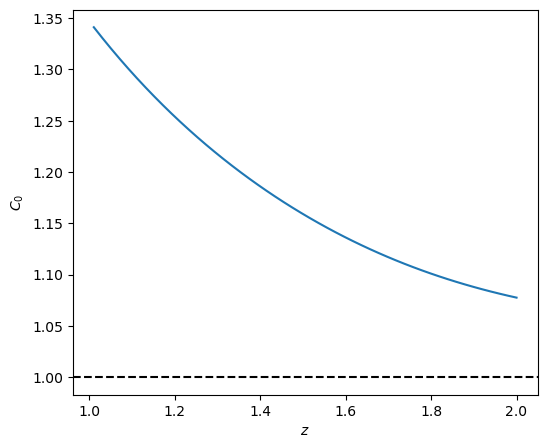

In [4]:
fig= plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)

ax.plot(z_values[z_values>1], Co_values[z_values>1])
ax.axhline(y=1, ls='--', c='black')

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$C_{0}$")

plt.show()

The whole idea of the approximation, lies into considering two limiting cases, where $\Delta \ll 1$ and $\Delta \gg 1$, which will create the following integrals:

$$
\int_0^1 \frac{\Delta-1}{\Delta^\beta} f(\Delta, z) d\Delta + f(C_0, z) \int_1^\infty \frac{\Delta-1}{\Delta^\beta} d\Delta = 0
$$

In [5]:
alpha, beta, F0 = 3, 3, 0.1

In [6]:
def f(D, z):
    exponent = D**(-2*alpha)/(2*alpha**2*F0**2/z)
    return np.exp(-exponent)

In [7]:
Delta_array = np.linspace(0.01, 1, 500)

In [8]:
def I1_integral(z):
    I1 = np.trapz((Delta_array-1)*f(Delta_array, z)/Delta_array**beta, Delta_array)
    return I1

In [9]:
def C0(z):
    factor = -18*F0**2/z
    ln_int = np.log(-2*I1_integral(z))
    
    return np.sqrt(factor*ln_int)

In [10]:
C0_approx = np.zeros_like(z_values[1:])

for idx, z in enumerate(z_values[1:]):
    C0_approx[idx] = C0(z)

In [11]:
C0_approx

array([3.89549416, 3.32145988, 2.9943445 , 2.77507161, 2.6141494 ,
       2.48915054, 2.38820587, 2.30434552, 2.23316047, 2.17170128,
       2.11790704, 2.07028647, 2.02772907, 1.98938791, 1.95460379,
       1.92285458, 1.89372047, 1.86685935, 1.84198915, 1.81887488,
       1.79731892, 1.77715365, 1.75823583, 1.7404422 , 1.72366599,
       1.70781418, 1.69280533, 1.67856772, 1.66503796, 1.65215973,
       1.63988282, 1.62816231, 1.61695785, 1.60623306, 1.5959551 ,
       1.58609417, 1.57662321, 1.56751754, 1.55875462, 1.55031383,
       1.54217622, 1.53432439, 1.52674229, 1.51941511, 1.51232916,
       1.50547175, 1.4988311 , 1.49239627, 1.48615707, 1.48010401,
       1.47422823, 1.46852144, 1.46297589, 1.4575843 , 1.45233987,
       1.44723619, 1.44226723, 1.43742734, 1.43271116, 1.42811366,
       1.42363008, 1.41925593, 1.41498696, 1.41081914, 1.40674865,
       1.40277189, 1.39888541, 1.39508596, 1.39137043, 1.38773589,
       1.38417952, 1.38069866, 1.37729075, 1.37395337, 1.37068

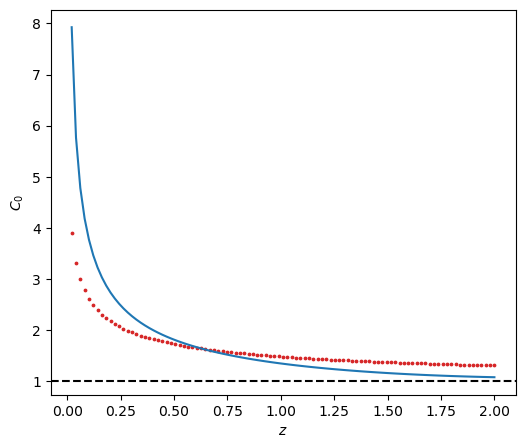

In [12]:
fig= plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)

ax.plot(z_values[1:], Co_values[1:])
ax.scatter(z_values[1:], C0_approx, c='tab:red', s=3)
ax.axhline(y=1, ls='--', c='black')

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$C_{0}$")

plt.show()

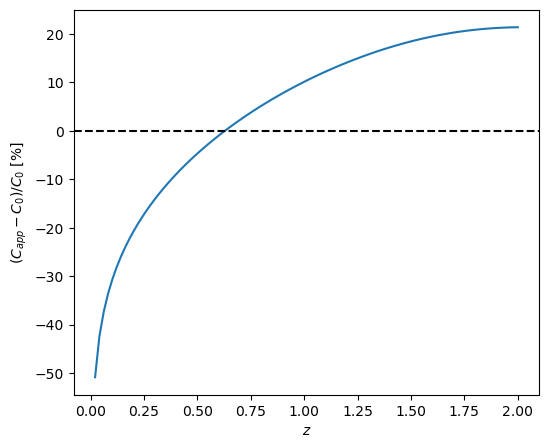

In [13]:
fig= plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)

ax.plot(z_values[1:], (C0_approx-Co_values[1:])/Co_values[1:]*100)

ax.axhline(y=0, ls='--', c='black')

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$(C_{app}-C_{0})/C_0$ [%]")

plt.show()

In [14]:
def g(D, Co, z):
    exponent = (D**(-alpha)-Co)**2/(2*alpha**2*F0**2/z)
    return np.exp(-exponent)

In [18]:
def Integral_full(Co, z):
    F_int = np.trapz((Delta_array-1)*g(Delta_array, Co, z)/Delta_array**beta, Delta_array)
    return F_int

In [19]:
Delta_full = np.linspace(0.01, 100, 800)

In [20]:
I_approx = np.zeros_like(z_values[1:])
I_full = np.zeros_like(z_values[1:])

for idx, z in enumerate(z_values[1:]):
    I_full[idx] = Integral_full(Co_values[1:][idx], z)
    I_approx[idx] = Integral_full(C0_approx[idx], z)

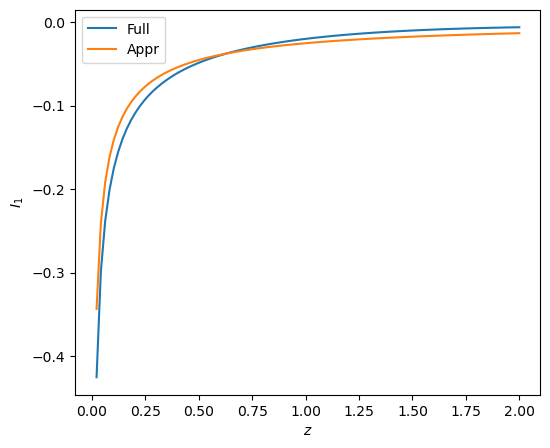

In [21]:
fig= plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)

ax.plot(z_values[1:], I_full, label='Full')
ax.plot(z_values[1:], I_approx, label='Appr')

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$I_1$")

plt.legend()
plt.show()

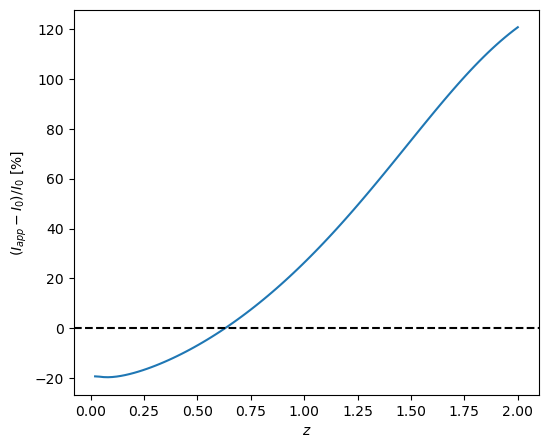

In [22]:
fig= plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)

ax.plot(z_values[1:], (I_approx-I_full)/I_full*100)

ax.axhline(y=0, ls='--', c='black')

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$(I_{app}-I_{0})/I_0$ [%]")

plt.show()